# Cars 4 You: Expediting Car Evaluations with ML

## 1. Data Import & Exploratory Data Analysis



#### **1.1. Importing the Libraries and Dataset**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train= pd.read_csv("train.csv").copy() #importing the dataset
test=pd.read_csv("test.csv").copy()


#### **1.2. Initial Analysis**

In [3]:
#numero de linhas e colunas
print(train.shape) 

(75973, 14)


In [4]:
display(train.head())

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


In [5]:
display(train.info()) # to see the data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


None

In [6]:
#definir as colunas como categoricas, numericas etc 
categorical_columns = train.select_dtypes(include=['object']).columns
numerical_columns = train.select_dtypes(include=['int64', 'float64']).columns
categorical_columns, numerical_columns

#futuramente fará sentido alterar o tipo de algumas colunas, como por exemplo year 

(Index(['Brand', 'model', 'transmission', 'fuelType'], dtype='object'),
 Index(['carID', 'year', 'price', 'mileage', 'tax', 'mpg', 'engineSize',
        'paintQuality%', 'previousOwners', 'hasDamage'],
       dtype='object'))

In [7]:
# Ao imprimir o inicio da tabela ja conseguimos perceber que temos missing values nomeadamente na coluna tax, e que temos inconsistências nas valores da variavel transmission por exemplo.
# No que toca a tipos de dados, as colunas year e previousOwners aparecem como float64 por causa dos missing values. Após imputação, serão convertidas para inteiros, uma vez que não fazem sentido como valores decimais. hasDamage será convertida para binária (0/1) para facilitar o encoding.
#falar do tipo de cada variavel, se é continua, categórica, ordinal, binária (?)

### 1.3. Categorical Variables Global Analysis
#### 1.3.1. Unique Values

In [8]:
#vamos imprimir os valores únicos de cada coluna categórica para percebermos se existem inconsistências
for col in categorical_columns:
    unique_values = train[col].unique()
    print(f"Column: {col}, Unique Values: {unique_values}")

Column: Brand, Unique Values: ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'FOR'
 'mercedes' 'Hyundai' 'w' 'ord' 'MW' 'bmw' nan 'yundai' 'BM' 'Toyot' 'udi'
 'Ope' 'AUDI' 'V' 'opel' 'pel' 'For' 'pe' 'Mercede' 'audi' 'MERCEDES'
 'OPEL' 'koda' 'FORD' 'Hyunda' 'W' 'Aud' 'vw' 'hyundai' 'skoda' 'ford'
 'TOYOTA' 'ercedes' 'oyota' 'toyota' 'SKODA' 'Skod' 'HYUNDAI' 'kod' 'v'
 'for' 'SKOD' 'aud' 'KODA' 'PEL' 'yunda' 'or' 'UDI' 'OYOTA' 'HYUNDA' 'mw'
 'OPE' 'mercede' 'ERCEDES' 'ercede' 'TOYOT' 'MERCEDE' 'ORD' 'ud' 'ope'
 'AUD' 'hyunda' 'skod' 'toyot']
Column: model, Unique Values: [' Golf' ' Yaris' ' Q2' ' FIESTA' ' 2 Series' '3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Clas' ' Q3' ' Fabia' ' A Class' ' Ka+'
 ' 3 Series' ' GLC Class' ' I30' ' C Class' ' Polo' ' E Class' ' C Clas'
 ' Q5' ' Up' ' Fiesta' ' C-HR' ' Mokka X' ' Corsa' ' Astra' ' TT'
 ' 5 Series' ' Aygo' ' 4 Series' ' SLK' ' Viva' ' T-Roc' 'Focus'
 ' EcoSport' ' Tucson' ' EcoSpor' nan ' X-CLASS' ' CL C

FALTAM COISAS NESTA SECÇÂO - alguns gráficos têm de estar aqui antes de haver qualquer tratamento (depois de tratados podem repetir-se)

#### 1.3.2. Visualization

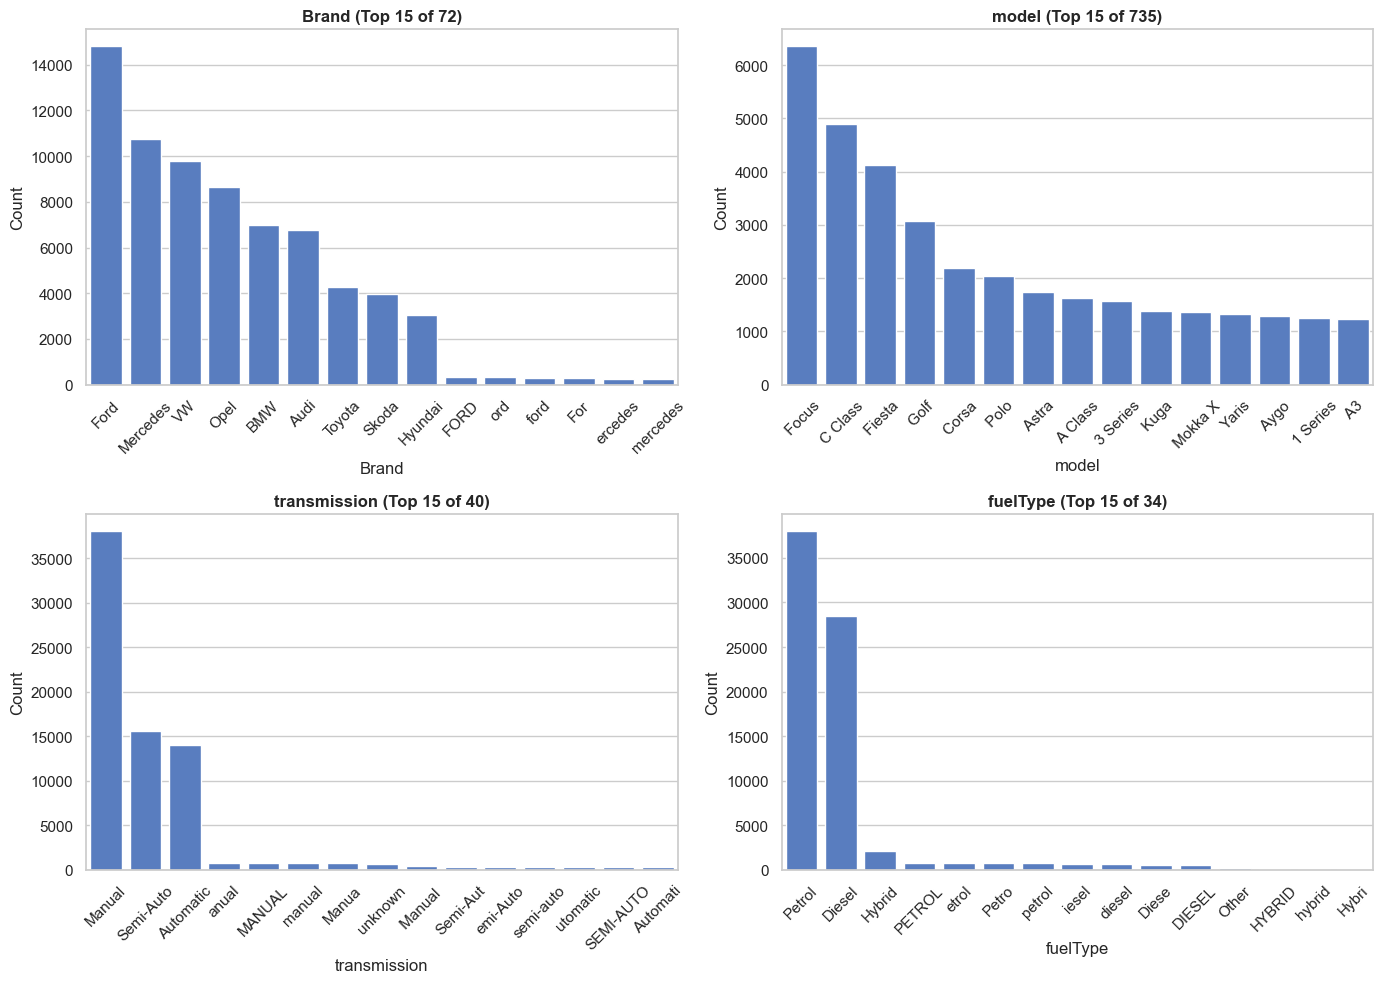

In [9]:
# Set style
sns.set(style="whitegrid", palette="muted")

n_cols = 2
n_rows = int(np.ceil(len(categorical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    ax = axes[i]
    n_unique = train[col].nunique()
    
    # If few unique values: countplot 
    if n_unique <= 10:
        sns.countplot(data=train, x=col, order=train[col].value_counts().index, ax=ax)
        ax.set_title(f"{col} (n={n_unique})", fontsize=12, weight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)
        
        total = len(train)
        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x() + p.get_width() / 2, height,
                    f'{height/total:.1%}', ha='center', va='bottom', fontsize=9)

    # If medium number of categories (10–20): barplot (top 10)
    elif n_unique <= 20:
        counts = train[col].value_counts().head(15)
        sns.barplot(x=counts.index, y=counts.values, ax=ax)
        ax.set_title(f"{col} (Top 15 of {n_unique})", fontsize=12, weight='bold')
        ax.tick_params(axis='x', rotation=45)

    # If too many unique (model): plot only top 10
    else:
        top15 = train[col].value_counts().head(15)
        sns.barplot(x=top15.index, y=top15.values, ax=ax)
        ax.set_title(f"{col} (Top 15 of {n_unique})", fontsize=12, weight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('Count')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [10]:
# ia fazer piecharts mas n faz sentido com tantas categorias, não se vê nada de jeito

#### 1.3.3. Interpretation

The categorical feature analysis reveals both dominant patterns and several data quality inconsistencies:

- <b>Brand</b>: The dataset is heavily skewed toward a few major manufacturers, with Ford, Mercedes, Volkswagen (VW), Opel, BMW and Audi representing a large share of all observations. However, duplicates such as "FORD" in uppercase indicate inconsistent capitalization. Additionally, there are clear truncation issues such as "ord", "For" and "ercedes", suggesting data-entry or parsing errors during dataset assembly. These anomalies will require targeted correction or mapping to their correct labels, which will be addressed later on.<br>

- <b>Model</b>: As expected, this variable displays very high cardinality; however, over 700 models seems too high - there are likely more capitalization / truncation errors in this column, they just don't appear in the top 15. The distribution is long-tailed, with only a few popular models (Focus, C Class, Fiesta, Golf) accounting for a significant portion of the data. Feature encoding will need to handle this imbalance carefully, so that our model doesn't start to predict only these models (generating a high accuracy but not being able to identify other types of cars).<br>

- <b>Transmission</b>: The data show strong dominance of Manual gearboxes (over half of all vehicles). Several near-duplicate entries ("manual", "MANUAL", "Manua", etc.) confirm the presence of text inconsistencies, that will later be standardized. We will also need to account for the ambiguous placeholders ("unknown").<br>

- <b>FuelType</b>: The dataset consists primarily of Petrol and Diesel vehicles, which together cover the vast majority of records. The appearance of variants such as "PETROL", "Petro", or "iesel" again suggests typographical noise that will need to be cleaned. Hybrid and Electric vehicles are underrepresented, which may affect model generalization for these classes.<br>

Overall, the categorical exploration highlights clear class imbalance and string normalization issues, both of which will be addressed in preprocessing to ensure consistency and reliable model performance.

### **1.4. Numerical Variables analysis**


In this section, we will analyse, generally, the values and study to know what will be needed in processing and cleaning 

We have the following numerical features in the dataset:
year,
price,
mileage,
tax,
mpg,
engineSize,
paintQuality%,
previousOwners,
hasDamage (althoug representing a binary feature)

-> Year: In this sub-section, we can see the global statistical data of this feature, as well as the distribution by year and percentages

In [11]:
#year column analysis
print(train['year'].describe())
#year column analysis - value count in percentage
print(train['year'].value_counts(normalize=True, dropna=False) * 100)
print(train[train['year'] % 1 ==0]['year'].describe()) # statistics with only integer values

count    74482.000000
mean      2017.096611
std          2.208704
min       1970.000000
25%       2016.000000
50%       2017.000000
75%       2019.000000
max       2024.121759
Name: year, dtype: float64
year
2019.000000    26.681847
2017.000000    21.252287
2016.000000    15.139589
2018.000000    13.562713
2015.000000     7.546102
2020.000000     4.177800
2014.000000     3.856633
2013.000000     2.503521
NaN             1.962539
2012.000000     0.629171
2011.000000     0.418570
2010.000000     0.317218
2009.000000     0.300107
2008.000000     0.207969
2007.000000     0.161900
2010.676968     0.107933
2023.116964     0.101352
2005.000000     0.084240
2006.000000     0.081608
2010.746403     0.076343
2023.977311     0.072394
2023.389822     0.069762
2011.210853     0.065813
2010.565009     0.061864
2023.267989     0.056599
2023.605276     0.051334
2009.816757     0.048702
2010.371546     0.046069
2004.000000     0.046069
2024.121759     0.044753
2003.000000     0.038171
2023.367078     0

add graphic and distribution by 5 years 

hasDamage

In [12]:
# check if hasdamage is either 1 or 0
print(train['hasDamage'].value_counts(dropna=False))

hasDamage
0.0    74425
NaN     1548
Name: count, dtype: int64


Previous owners

In [13]:
#check if previous owners is an integer
print(train['previousOwners'].value_counts(dropna=False))
print(train['previousOwners'].describe()) #media de todos 
print(train[(train['previousOwners'] >= 0) & (train['previousOwners'] % 1 == 0)]['previousOwners'].describe()) #media de valores que sao inteiros e positivos


previousOwners
 0.000000    14879
 4.000000    14763
 1.000000    14754
 3.000000    14649
 2.000000    14644
 NaN          1550
-2.340306       84
 6.258231       78
 6.245835       64
-2.345650       58
-2.339360       58
 6.258371       50
 6.233082       46
-2.299439       43
 6.230180       37
-2.335123       37
-2.312260       34
 6.248251       32
-2.337445       25
 6.217724       21
 6.241779       20
-2.340102       17
 6.227898       15
-2.317331       15
Name: count, dtype: int64
count    74423.000000
mean         1.994580
std          1.472981
min         -2.345650
25%          1.000000
50%          2.000000
75%          3.000000
max          6.258371
Name: previousOwners, dtype: float64
count    73689.000000
mean         1.995427
std          1.417058
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: previousOwners, dtype: float64


In [14]:
#analyse paintquality - percentage of values
print(train['paintQuality%'].value_counts(normalize=True, dropna=False) * 100)
# checking how many negative values are in the paintquality column
print(train[train['paintQuality%'] < 0]['paintQuality%'].count()) # --> result is 0
# how many values > 100 in paintquality
print(train[train['paintQuality%'] > 100]['paintQuality%'].count()) 
#descriptive statistics for paintquality 
print(train['paintQuality%'].describe())
#statistical general analysis of the "correct" (at least between the percentual appropriate range) 
print(train[(train['paintQuality%'] >= 0) & (train['paintQuality%'] <= 100)]['paintQuality%'].describe())

paintQuality%
NaN           2.005976
34.000000     1.509747
94.000000     1.484738
54.000000     1.466310
32.000000     1.457097
                ...   
125.453599    0.030274
2.725153      0.027641
1.638913      0.025009
125.188729    0.022376
3.254760      0.019744
Name: proportion, Length: 89, dtype: float64
0
367
count    74449.000000
mean        64.590667
std         21.021065
min          1.638913
25%         47.000000
50%         65.000000
75%         82.000000
max        125.594308
Name: paintQuality%, dtype: float64
count    74082.000000
mean        64.290118
std         20.633703
min          1.638913
25%         47.000000
50%         64.000000
75%         82.000000
max         99.000000
Name: paintQuality%, dtype: float64


In [15]:
print(train[train['paintQuality%'] < 0]['paintQuality%'].value_counts(normalize=True, dropna=False) * 100)


Series([], Name: proportion, dtype: float64)


In [16]:
# analyzing the engineSize column
print(train['engineSize'].value_counts(dropna=False))

engineSize
 2.000000    20105
 1.000000    13615
 1.500000     9156
 1.400000     7432
 1.600000     6381
 1.200000     4750
 3.000000     3806
 2.100000     3624
 NaN          1516
 1.800000     1192
 1.300000      920
 1.700000      618
 1.100000      385
 2.500000      312
 2.200000      295
 4.000000      295
 2.300000      181
 0.000000      180
 2.900000      116
-0.103493       84
 2.631200       80
 0.307074       65
 3.723712       63
 2.985793       52
 0.739534       52
 0.186425       52
 2.064119       51
 4.400000       46
 2.400000       43
 0.154529       39
 5.000000       38
 3.739235       38
 0.313407       35
 5.500000       31
 3.822758       27
 2.800000       26
 2.619641       25
 0.162866       24
 1.900000       23
 0.191462       21
 4.200000       20
 3.200000       19
 6.200000       19
 2.781776       19
 0.371127       18
 4.700000       18
 5.200000       17
 2.663113       17
 3.500000       12
 2.700000        7
 0.600000        4
 5.400000        2
 

In [17]:
# engine size descriptive statistics
print(train['engineSize'].describe())
print(train[train['engineSize'] > 0]['engineSize'].describe())



count    74457.000000
mean         1.660136
std          0.573462
min         -0.103493
25%          1.200000
50%          1.600000
75%          2.000000
max          6.600000
Name: engineSize, dtype: float64
count    74193.000000
mean         1.666161
std          0.565495
min          0.154529
25%          1.200000
50%          1.600000
75%          2.000000
max          6.600000
Name: engineSize, dtype: float64


In [18]:
#assessing the mileage column  
train['mileage'].value_counts(dropna=False)



mileage
NaN        1463
1000.0      577
10.0        560
5000.0      507
6000.0      340
           ... 
28088.0       1
7955.0        1
96040.0       1
2958.0        1
69072.0       1
Name: count, Length: 34809, dtype: int64

In [19]:
train['mileage'].describe()


count     74510.000000
mean      23004.184088
std       22129.788366
min      -58540.574478
25%        7423.250000
50%       17300.000000
75%       32427.500000
max      323000.000000
Name: mileage, dtype: float64

In [20]:
train[train['mileage']>0]['mileage'].describe()

count     74141.000000
mean      23352.797092
std       21620.630248
min           1.000000
25%        7556.000000
50%       17416.000000
75%       32510.000000
max      323000.000000
Name: mileage, dtype: float64

In [21]:
#tax collumn analysis
print(train['tax'].value_counts(dropna=False))
print(train['tax'].describe())
print(train[train['tax']>=0]['tax'].describe())


tax
145.0    32861
NaN       7904
150.0     7400
30.0      5781
20.0      5610
         ...  
130.0        1
520.0        1
295.0        1
245.0        1
535.0        1
Name: count, Length: 66, dtype: int64
count    68069.000000
mean       120.329078
std         65.521176
min        -91.121630
25%        125.000000
50%        145.000000
75%        145.000000
max        580.000000
Name: tax, dtype: float64
count    67691.000000
mean       121.259276
std         64.493191
min          0.000000
25%        125.000000
50%        145.000000
75%        145.000000
max        580.000000
Name: tax, dtype: float64


In [22]:
# mpg column analysis
train['mpg'].value_counts(dropna=False)



mpg
NaN     7926
60.1    4195
65.7    3188
54.3    2791
64.2    2459
        ... 
42.4       1
61.1       1
38.1       1
6.0        1
53.5       1
Name: count, Length: 218, dtype: int64

In [23]:
print(train['mpg'].describe())
print(train[train['mpg']>0]['mpg'].describe())

count    68047.000000
mean        55.152666
std         16.497837
min        -43.421768
25%         46.300000
50%         54.300000
75%         62.800000
max        470.800000
Name: mpg, dtype: float64
count    68011.000000
mean        55.204844
std         16.345534
min          1.100000
25%         46.300000
50%         54.300000
75%         62.800000
max        470.800000
Name: mpg, dtype: float64


In [24]:
#price analysis
print(train['price'].value_counts(dropna=False))
print(train['price'].describe())

price
9995     406
10995    360
8995     359
11000    334
12995    329
        ... 
21320      1
22416      1
39923      1
6301       1
25785      1
Name: count, Length: 11048, dtype: int64
count     75973.000000
mean      16881.889553
std        9736.926322
min         450.000000
25%       10200.000000
50%       14699.000000
75%       20950.000000
max      159999.000000
Name: price, dtype: float64


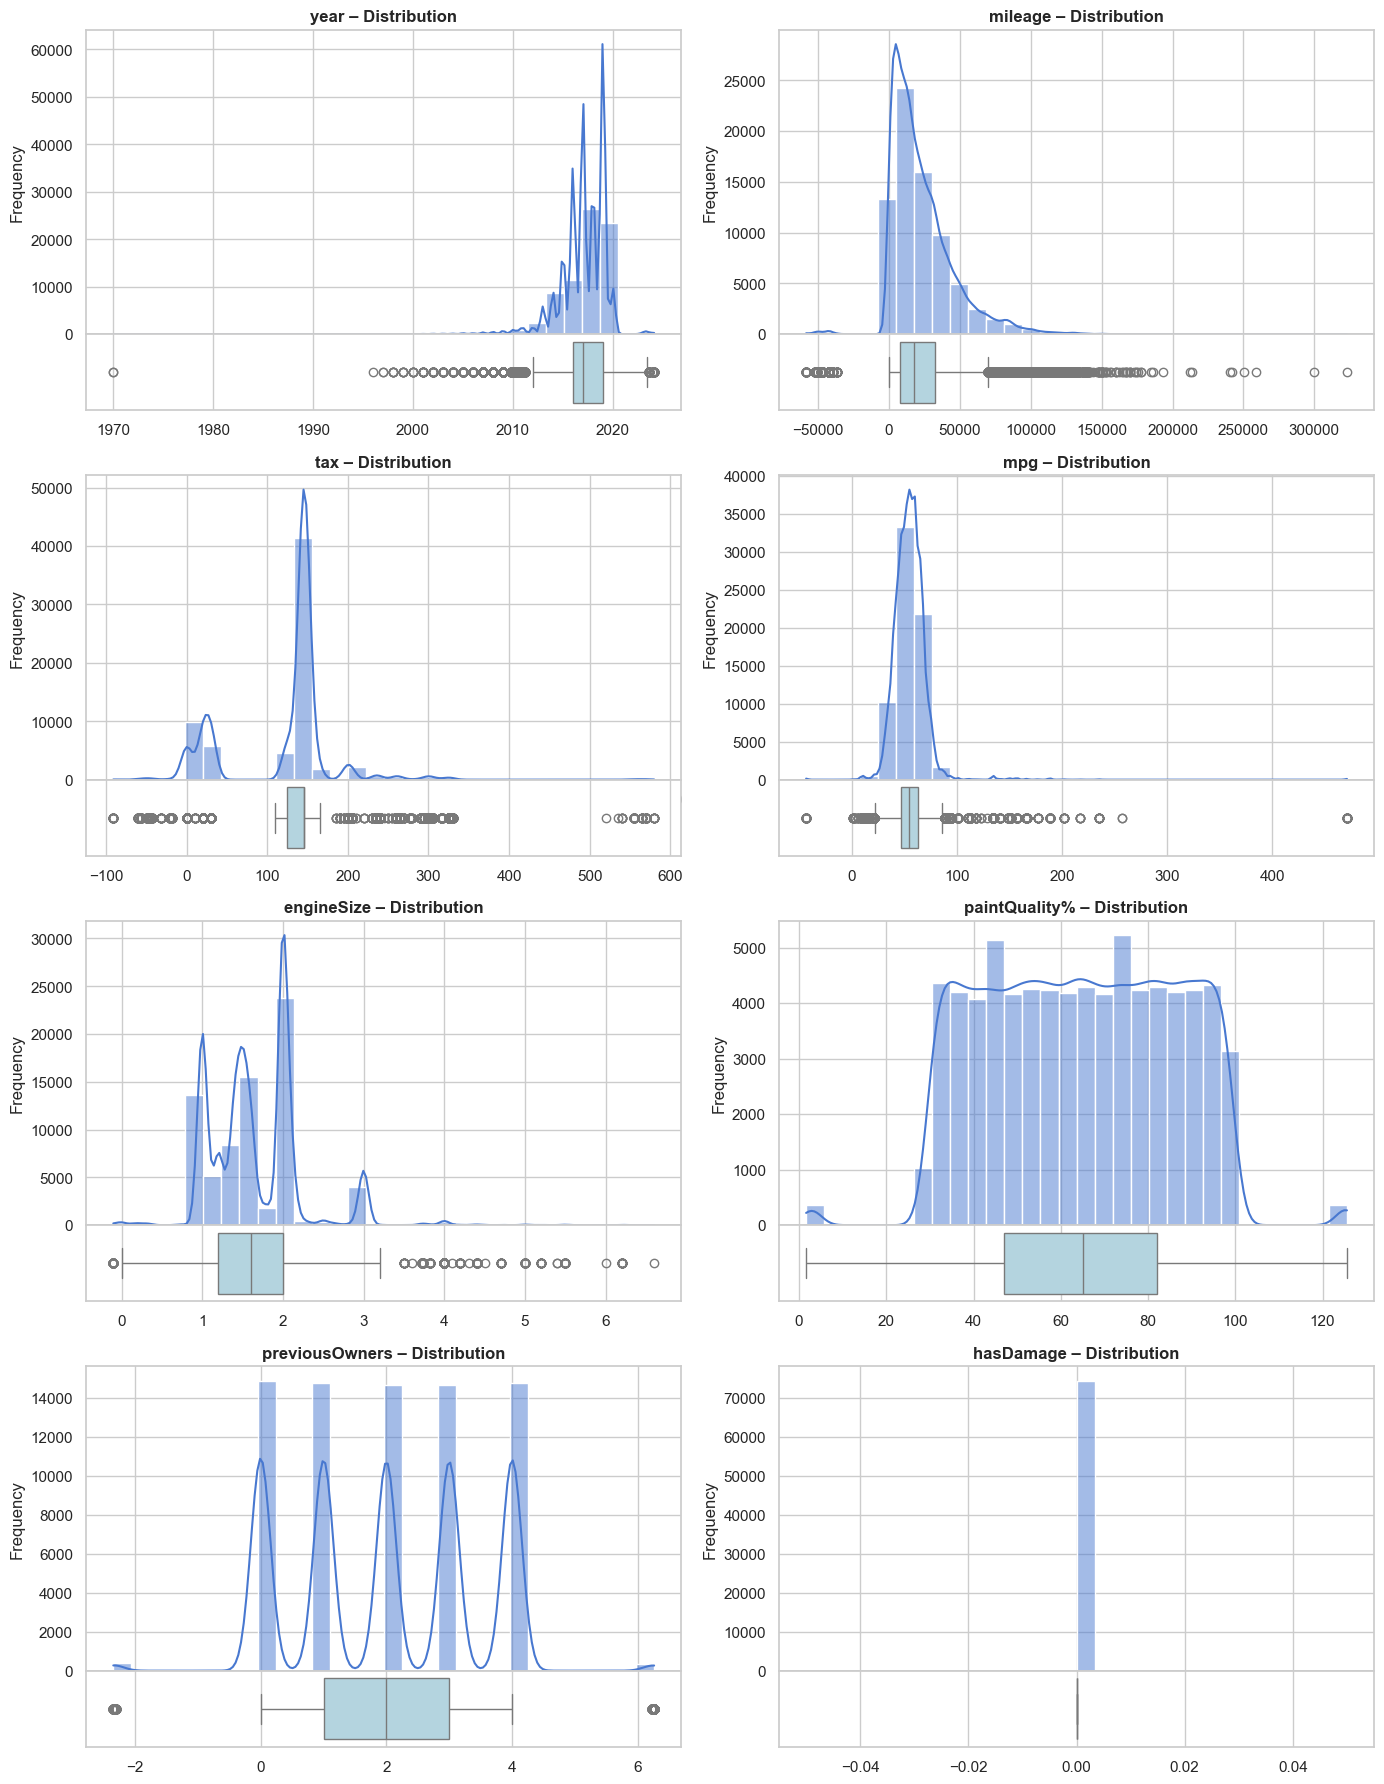

In [25]:
sns.set(style="whitegrid", palette="muted")

# Identify numerical columns 
numerical_columns = train.select_dtypes(include=['int64', 'float64']).columns
# Exclude target variable 'price' from the plots and carID(doesn't make sense to plot it)
numerical_columns = numerical_columns.drop(['price', 'carID'])

n_cols = 2
n_rows = int(np.ceil(len(numerical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    ax = axes[i]

    # Plot histogram with KDE overlay
    sns.histplot(train[col], kde=True, bins=30, ax=ax)
    ax.set_title(f"{col} – Distribution", fontsize=12, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

    # Boxplot below histogram 
    ax_box = ax.inset_axes([0, -0.25, 1, 0.25])
    sns.boxplot(x=train[col], ax=ax_box, color='lightblue')
    ax_box.set_xlabel('')
    ax_box.set_yticks([])
    ax_box.set_title('')

# Remove empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1.5. Cross analysis

## 2. 

In [26]:
#conseguimos perceber que há inconsistencias em todas as colunas categóricas
#começamos por passar todas as colunas categoricas para upper case e retirar os espaços em branco do inicio e fim da string
for column in categorical_columns:
    train[column] = train[column].str.upper().str.strip()  
    print(f"Unique values in column '{column}' after stripping and uppercasing: {train[column].unique()}") 


Unique values in column 'Brand' after stripping and uppercasing: ['VW' 'TOYOTA' 'AUDI' 'FORD' 'BMW' 'SKODA' 'OPEL' 'MERCEDES' 'FOR'
 'HYUNDAI' 'W' 'ORD' 'MW' nan 'YUNDAI' 'BM' 'TOYOT' 'UDI' 'OPE' 'V' 'PEL'
 'PE' 'MERCEDE' 'KODA' 'HYUNDA' 'AUD' 'ERCEDES' 'OYOTA' 'SKOD' 'KOD'
 'YUNDA' 'OR' 'ERCEDE' 'UD']
Unique values in column 'model' after stripping and uppercasing: ['GOLF' 'YARIS' 'Q2' 'FIESTA' '2 SERIES' '3 SERIES' 'A3' 'OCTAVIA'
 'PASSAT' 'FOCUS' 'INSIGNIA' 'A CLAS' 'Q3' 'FABIA' 'A CLASS' 'KA+'
 'GLC CLASS' 'I30' 'C CLASS' 'POLO' 'E CLASS' 'C CLAS' 'Q5' 'UP' 'C-HR'
 'MOKKA X' 'CORSA' 'ASTRA' 'TT' '5 SERIES' 'AYGO' '4 SERIES' 'SLK' 'VIVA'
 'T-ROC' 'ECOSPORT' 'TUCSON' 'ECOSPOR' nan 'X-CLASS' 'CL CLASS' 'IX20'
 'I20' 'RAPID' 'A1' 'AURIS' 'SHARAN' 'ADAM' 'X3' 'A8' 'GLS CLASS' 'B-MAX'
 'A4' 'KONA' 'I10' 'MOKKA' 'S-MAX' 'X2' 'CROSSLAND X' 'TIGUAN' 'A5'
 'GLE CLASS' 'ZAFIRA' 'IONIQ' 'A6' 'MONDEO' 'YETI OUTDOOR' 'X1' 'SCALA'
 'S CLASS' '1 SERIES' 'KAMIQ' 'KUGA' 'TOURNEO CONNECT' 'Q7' 'GLA C

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_81236/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_81236/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_81236/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_81236/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

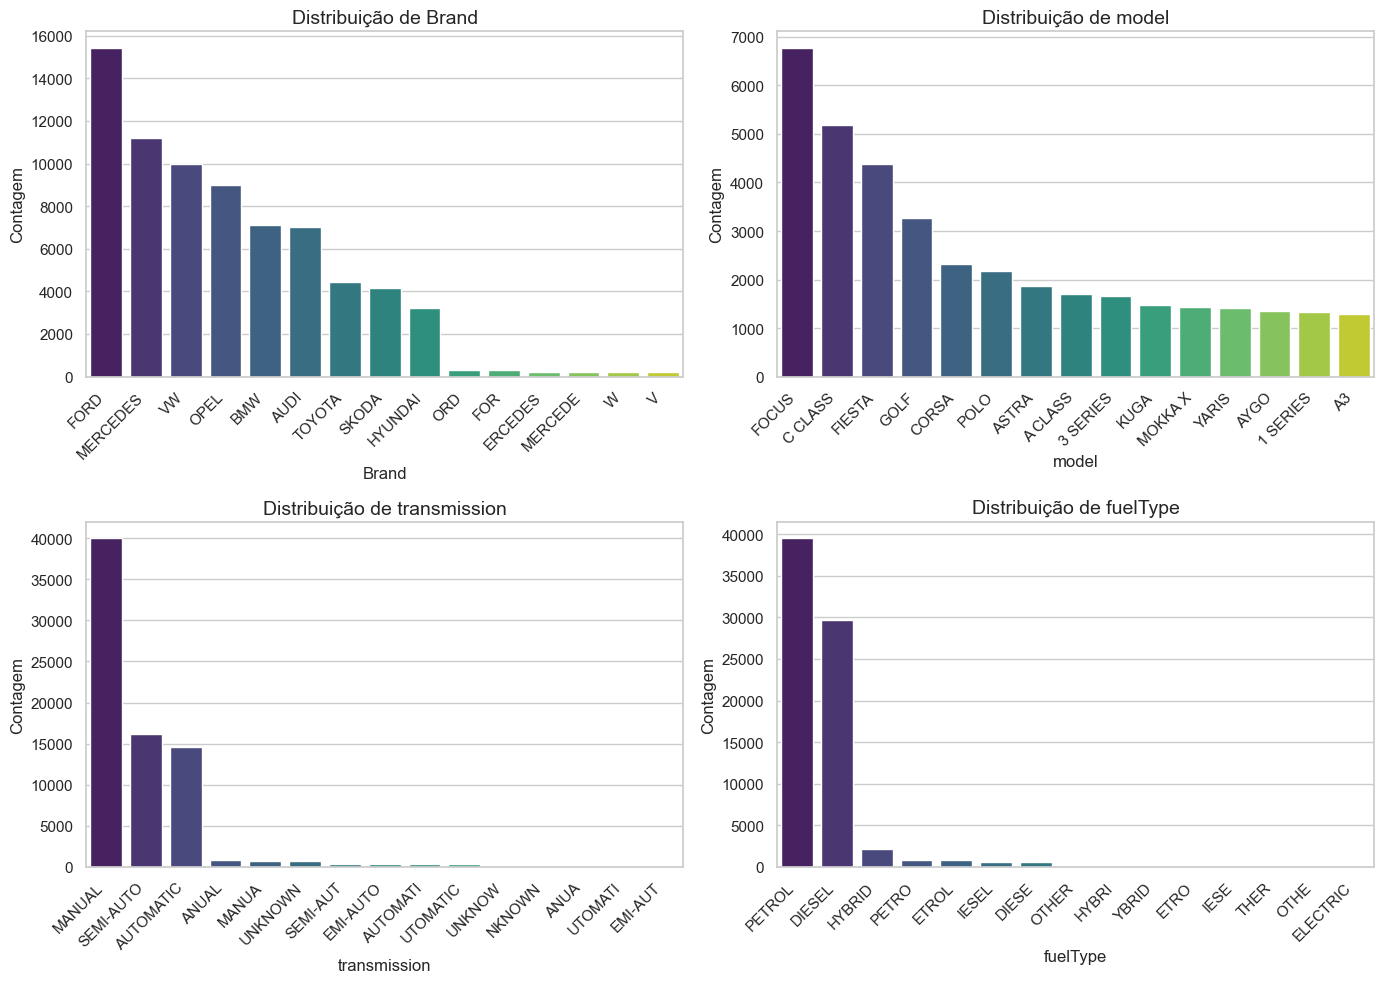

In [27]:
sns.set(style="whitegrid")

# Cria um subplot por variável
n_cols = 2
n_rows = (len(categorical_columns) + 1) // n_cols

plt.figure(figsize=(14, 5 * n_rows))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    
    # Mostra as 15 categorias mais comuns
    top_values = train[col].value_counts().head(15)
    
    sns.barplot(
        x=top_values.index,
        y=top_values.values,
        palette="viridis"
    )
    
    plt.title(f"Distribuição de {col}", fontsize=14)
    plt.ylabel("Contagem")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [28]:
# o meu objetivo com estes graficos era perceber se existia a possibilidade de definir um threshold de frequencia para distinguir valores validos de invalidos
# so que nao funciona para os modelos claramente
# no entanto para as outras var alem do model acho que pode funcionar, so que por exemplo em fueltype tens o eletric que é valido so que como só tem uma amostra vai acabar por nao estar na lista dos validos, mas dá para resolver acho eu

In [29]:
train['model'].value_counts()

model
FOCUS             6775
C CLASS           5194
FIESTA            4384
GOLF              3261
CORSA             2319
                  ... 
TIGUAN ALLSPAC       1
8 SERIE              1
230                  1
FOX                  1
TERRACAN             1
Name: count, Length: 296, dtype: int64

In [30]:
#esta função eu acabei por perceber que não funciona porque por exemplo para o caso de UD que pode ser tanto audi como hyundai, e se eu substituir logo por audi ou hyundai (dependendo do que vai aparecer primeiro), depois quando chegar a hyundai ou audi ja nao vou conseguir perceber que é ambiguo

def normalize_by_containment(values):
    valores_unicos = [v for v in pd.Series(values).dropna().unique() if isinstance(v, str)]
    lista_limpa = []
    mapping = {}
    ambiguos = set()

    for v in valores_unicos:
        # procura valores já na lista que contenham ou sejam contidos por v
        candidatos = [x for x in lista_limpa if v in x or x in v]

        # se não há candidatos, adiciona
        if not candidatos:
            lista_limpa.append(v)
            mapping[v] = v
            continue

        # se há mais de um candidato, é ambíguo — não muda, mas regista
        if len(candidatos) > 1:
            mapping[v] = v
            ambiguos.add(v)
            continue

        # se há só um candidato
        c = candidatos[0]
        if v in c:
            # valor é substring do existente
            mapping[v] = c
        elif c in v:
            # valor é superstring — substitui o existente
            lista_limpa.remove(c)
            lista_limpa.append(v)
            # atualiza todos que apontavam para c
            for k in list(mapping.keys()):
                if mapping[k] == c:
                    mapping[k] = v
            mapping[v] = v
        else:
            mapping[v] = v  # fallback (não devia acontecer)

    valores_normalizados = [mapping.get(v, v) for v in values]
    return valores_normalizados, sorted(list(ambiguos))


ambiguous_summary = {}

for col in categorical_columns:
    print(f"\nNormalizando coluna: {col}")

    # aplica a função
    train[col], ambiguos = normalize_by_containment(train[col])

    # guarda os ambíguos encontrados (se houver)
    if ambiguos:
        ambiguous_summary[col] = ambiguos
        print(f" Valores ambíguos encontrados ({len(ambiguos)}): {ambiguos}")
    else:
        print(" Nenhum valor ambíguo encontrado.")




Normalizando coluna: Brand
 Valores ambíguos encontrados (1): ['W']

Normalizando coluna: model
 Valores ambíguos encontrados (18): ['A', 'ADA', 'CADDY', 'I', 'IQ', 'K', 'KA', 'M', 'Q', 'RAV', 'RS', 'S CLAS', 'SL', 'T', 'U', 'VERS', 'X', 'Z']

Normalizando coluna: transmission
 Nenhum valor ambíguo encontrado.

Normalizando coluna: fuelType
 Nenhum valor ambíguo encontrado.


In [31]:
#ignorem esta função sou eu a pensar, mas aqui esta vai ser a função que vou usar para normalizar os valores depois de ter a lista dos valores válidos 


# aqui vou ter de criar uma lista so com velores que nao tem interseção e a partir daí começo a fazer as comparações
# ha aqui tambem um problema que é "etro" tambem esta em petrol e other com a função do contain... 
# é preciso mudar isto de modo a que, quando estamos a analisar um valor tambem sejam tidos em conta os valores que vêm a seguir para analise, porque por exemplo, UD pode estar para representar AUDI mas tambem Hyundai, nao sabemos de que forma os dados foram alterador, e para estar a prova de bala, preciso que nao se susbtituam logo valores sabendo que pode vir um nome a seguir que o torne ambiguo, faz sentido?


#o que quero fazer é, criar ua lista de todas os valores unicos que nao estao contidos uns nos outros
# a partir daí, das palavras que sobraraam ver as que estão contidas em apenas 1 palavra da lista inicial 
# se estiverem contidas em mais do que uma palavra, são ambiguas e não se alteram
#se estiveram contidas numa so palavra entao passam a ser a palavra em que estao contidas
#depois para as palavras que deram ambiguas, vou criar uma função que recebe a lista de ambiguos e uma coluna de suporte, isto é, para cada valor ambiguo, vamos verificar na coluna de suporte se ha mais iguais por exemplo; temos uma marca ambigua, vamos ver se na coluna model ha mais models iguais, se houver, então alteramos a marca para a marca que está na coluna model
# os que nao nao houver outro model assim, 


def normalize_by_containment(values):
    valores_unicos = [v for v in pd.Series(values).dropna().unique() if isinstance(v, str)]
    lista_limpa = []
    mapping = {}
    ambiguos = set()

    for v in valores_unicos:
        # procura valores já na lista que contenham ou sejam contidos por v
        candidatos = [x for x in lista_limpa if v in x or x in v]

        # se não há candidatos, adiciona
        if not candidatos:
            lista_limpa.append(v)
            mapping[v] = v
            continue

        # se há mais de um candidato, é ambíguo — não muda, mas regista
        if len(candidatos) > 1:
            mapping[v] = v
            ambiguos.add(v)
            continue

        # se há só um candidato
        c = candidatos[0]
        if v in c:
            # valor é substring do existente
            mapping[v] = c
        elif c in v:
            # valor é superstring — substitui o existente
            lista_limpa.remove(c)
            lista_limpa.append(v)
            # atualiza todos que apontavam para c
            for k in list(mapping.keys()):
                if mapping[k] == c:
                    mapping[k] = v
            mapping[v] = v
        else:
            mapping[v] = v  # fallback (não devia acontecer)

    valores_normalizados = [mapping.get(v, v) for v in values]
    return valores_normalizados, sorted(list(ambiguos))


In [32]:
#normalizar os valores de cada coluna categórica
ambiguous_summary = {}

for col in categorical_columns:
    print(f"\n Coluna normalizada: {col}")

    train[col], ambiguos = normalize_by_containment(train[col])

    if ambiguos:
        ambiguous_summary[col] = ambiguos
        print(f" Valores ambíguos encontrados ({len(ambiguos)}): {ambiguos}")
    else:
        print(" Nenhum valor ambíguo encontrado.")
  


 Coluna normalizada: Brand
 Valores ambíguos encontrados (1): ['W']

 Coluna normalizada: model
 Valores ambíguos encontrados (18): ['A', 'ADA', 'CADDY', 'I', 'IQ', 'K', 'KA', 'M', 'Q', 'RAV', 'RS', 'S CLAS', 'SL', 'T', 'U', 'VERS', 'X', 'Z']

 Coluna normalizada: transmission
 Nenhum valor ambíguo encontrado.

 Coluna normalizada: fuelType
 Nenhum valor ambíguo encontrado.


#### **Missing Values**

In [33]:
#counting the number of duplicated rows
print(train.duplicated().sum()) #0 duplicated rows
#porque seria importante?

0


In [34]:
#contagem de missing values por coluna e qual a percentagem 
missing_values = train.isnull().sum()
missing_percentage = (train.isnull().sum() / len(train)) * 100
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print(missing_data)
#lots of missing values in all the colums except the carID and price

                Missing Values  Percentage
carID                        0    0.000000
Brand                     1521    2.002027
model                     1517    1.996762
year                      1491    1.962539
price                        0    0.000000
transmission              1522    2.003343
mileage                   1463    1.925684
fuelType                  1511    1.988864
tax                       7904   10.403696
mpg                       7926   10.432654
engineSize                1516    1.995446
paintQuality%             1524    2.005976
previousOwners            1550    2.040198
hasDamage                 1548    2.037566


In [35]:
# temos duas categorias principais de missing values, de 2% e de 10% de missing values 
# as com percentagem de missing values de 2% penso que nao consistem numa percentagem de missing values significativa 
# vamos analisar a distribuicao dos dados para perceber que abordagem faz mais sentido
# analisar garficos para perceber o que fazer com os missing values 


<Axes: >

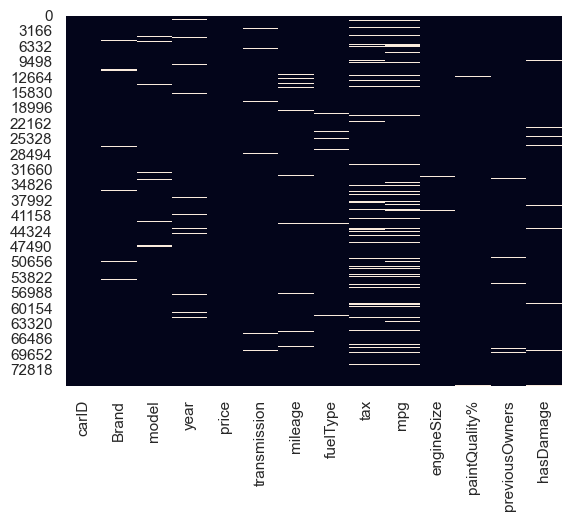

In [36]:
sns.heatmap(train.isna(), cbar=False)

In [37]:
# Com este gráfico podemos reparar que quase todos os missing values de tax e mpg que são as variaveis que têm % de missing values mais significativa, estão juntos, isto faz sentido uma vez que carros eletricos ou hibridos(aqui nao sei se se aplica), nao têm mpg e estao muitas vezes isentos de taxas

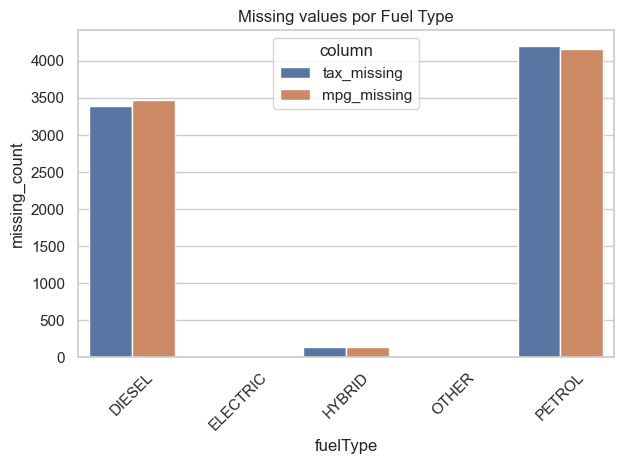

In [38]:
train['tax_missing'] = train['tax'].isna()
train['mpg_missing'] = train['mpg'].isna()

missing_counts = train.groupby('fuelType')[['tax_missing', 'mpg_missing']].sum().reset_index()
missing_melted = missing_counts.melt(id_vars='fuelType', var_name='column', value_name='missing_count')


sns.barplot(data=missing_melted, x='fuelType', y='missing_count', hue='column')
plt.title('Missing values por Fuel Type')
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()



In [39]:
# fiz este grafico para tentar provar o meu ponto anterior e o grafico provou me exatamente o contrario, giro

## Alguns graficos e estatisticas que podem fazer sentido (não acabei)

In [40]:
#calculate some basic statistics for numerical columns
display(train.describe())

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


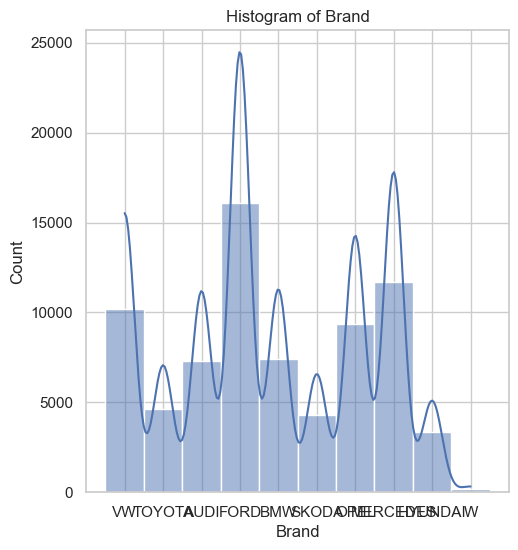

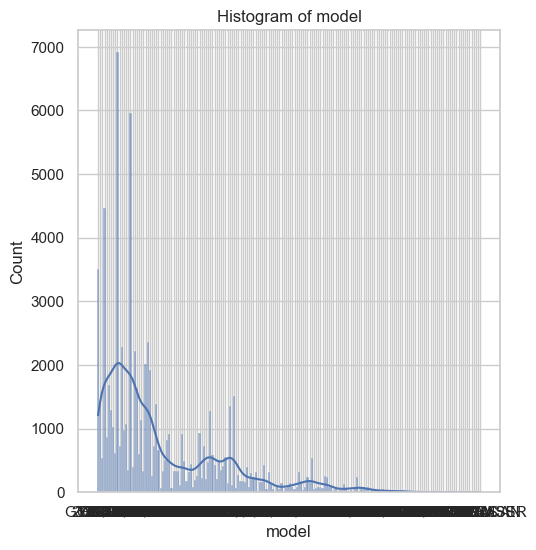

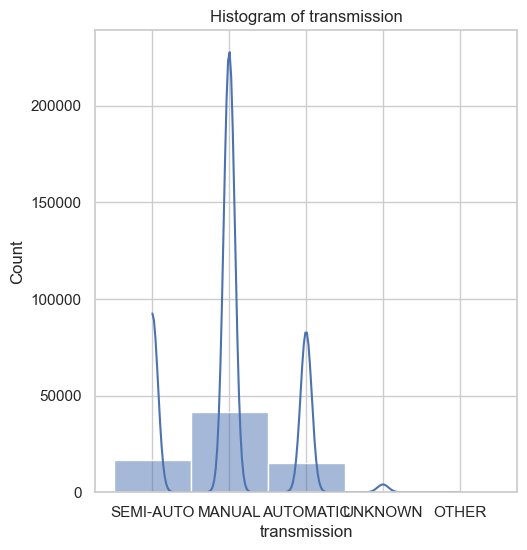

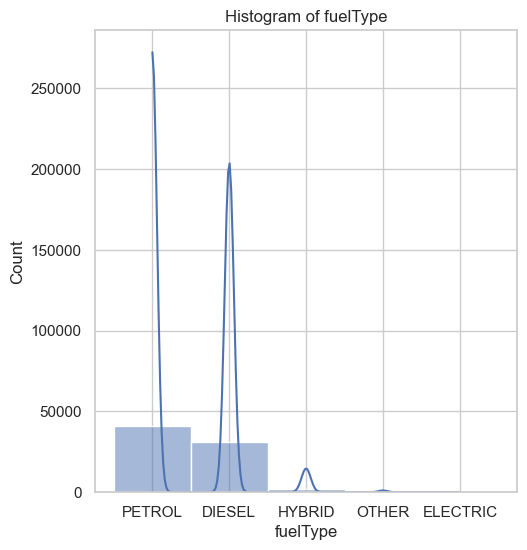

In [41]:
#Create graphics for numerical columns(histograms, boxplots, scatter plots)
numerical_columns = train.select_dtypes(include=[np.number]).columns.tolist()
for column in categorical_columns:
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    sns.histplot(train[column].dropna(), kde=True)
    plt.title(f'Histogram of {column}')
    
    plt.show()

#fazer mais graficos e tirar boas conclusoes dos gráficos 


## Analyzing the numerical data 

We have the following numerical features in the dataset:
year,
price,
mileage,
tax,
mpg,
engineSize,
paintQuality%,
previousOwners,
hasDamage (althoug representing a binary feature)

Each of them, has its own constraints, and this values should satisfy these conditions
\[
\begin{aligned}
\text{year} &\in [1900, 2020] \\[6pt]
\text{mileage} &\geq 0 \\[6pt]
\text{tax} &\geq 0 \\[6pt]
\text{mpg} &> 0 \\[6pt]
\text{engineSize} &> 0 \\[6pt]
\text{paintQuality\%} &\in [0, 100] \\[6pt]
\text{previousOwners} &\in \mathbb{N}_0 = \{0, 1, 2, \dots\} \\[6pt]
\text{hasDamage} &\in \{0, 1\}
\end{aligned}
\]

Analisando as médias e os restantes valores é possível constatar que não há grandes diferenças nos valores descritivos entre os previous owners n filtrados e aqueles cujos valores são somente inteiro positivos 
--> Decidir o que fazer aos Nan e aos valores negativos

The "year" column contains values between 1970 and approximately 2024. The presence of decimal values may result from typos or from calculating the fractional number of years (i.e. including the number of months). However, the exact number of months a car has is typically not very relevant for price estimation - the car's age in full years matters most. Additionally, users will probably not calculate (or at least not correctly) the exact fractional age of the car. 

-> Therefore, we round all "year" values down to the floor integer. 

Moreover, the entries that didn't contain a "year" value were removed from the dataset. This decision is based on the fact that a car's year is one of the most relevant factors in determining its price. Replacing these missing values with a constant or with a statistical estimate (such as the mean or median) could lead to unreliable results. Since they represent only about 2% of the dataset, removing them was considered the safest option to ensure reliable outcomes. 

In [42]:
train = train.dropna(subset=['year'])  #removing rows with missing year values
train['year'] = np.floor(train['year']) #rounding down to the nearest integer

test['year'] = np.floor(test['year'])


In [43]:
train['year'].describe()

count    74482.000000
mean      2017.091821
std          2.211113
min       1970.000000
25%       2016.000000
50%       2017.000000
75%       2019.000000
max       2024.000000
Name: year, dtype: float64

In [44]:
train['year'].value_counts(normalize=True, dropna=False) * 100

year
2019.0    27.215972
2017.0    21.677721
2016.0    15.442657
2018.0    13.834215
2015.0     7.697162
2020.0     4.261432
2014.0     3.933836
2013.0     2.553637
2012.0     0.669961
2010.0     0.648479
2011.0     0.514218
2023.0     0.393384
2009.0     0.355791
2008.0     0.212132
2007.0     0.165141
2005.0     0.085927
2006.0     0.083242
2004.0     0.046991
2024.0     0.045649
2022.0     0.041621
2003.0     0.038936
2002.0     0.033565
2001.0     0.020139
2000.0     0.008056
1998.0     0.006713
1999.0     0.006713
1970.0     0.002685
1997.0     0.002685
1996.0     0.001343
Name: proportion, dtype: float64

In [45]:
train.drop("hasDamage", axis=1)

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,tax_missing,mpg_missing
0,69512,VW,GOLF SV,2016.0,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4.000000,True,False
1,53000,TOYOTA,YARIS,2019.0,13790,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1.000000,False,False
2,6366,AUDI,Q2,2019.0,24990,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4.000000,False,False
3,29021,FORD,FIESTA,2018.0,12500,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,-2.340306,False,False
4,10062,BMW,2 SERIES,2019.0,22995,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3.000000,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,MERCEDES,GLC CLASS,2015.0,13498,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0.000000,False,False
75969,6265,AUDI,Q3,2013.0,12495,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2.000000,False,False
75970,54886,TOYOTA,AYGO,2017.0,8399,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3.000000,False,False
75971,860,AUDI,Q3,2015.0,12990,MANUAL,69072.0,DIESEL,125.0,60.100000,2.0,74.0,2.000000,False,False


Previous owners

In [46]:
#check if previous owners is an integer
print(train['previousOwners'].value_counts(dropna=False))


previousOwners
 0.000000    14588
 4.000000    14483
 1.000000    14458
 2.000000    14364
 3.000000    14346
 NaN          1523
-2.340306       82
 6.258231       76
 6.245835       63
-2.339360       58
-2.345650       55
 6.258371       49
 6.233082       44
-2.299439       43
 6.230180       37
-2.335123       37
-2.312260       34
 6.248251       30
-2.337445       25
 6.217724       21
 6.241779       20
-2.340102       16
 6.227898       15
-2.317331       15
Name: count, dtype: int64


In [47]:
print(train['previousOwners'].describe()) #media de todos 


count    72959.000000
mean         1.994568
std          1.473148
min         -2.345650
25%          1.000000
50%          2.000000
75%          3.000000
max          6.258371
Name: previousOwners, dtype: float64


In [48]:
print(train[(train['previousOwners'] >= 0) & (train['previousOwners'] % 1 == 0)]['previousOwners'].describe()) #media de valores que sao inteiros e positivos


count    72239.000000
mean         1.995543
std          1.417199
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: previousOwners, dtype: float64


In [49]:
# valores negativos passam a absolutos 
train['previousOwners'] = train['previousOwners'].abs()

# valores inteiros passam a arrendados 
train['previousOwners'] = train['previousOwners'].round()

# calcular media nova 
# ver se mean ou median ou mode 
train['previousOwners'] = train['previousOwners'].fillna(train['previousOwners'].mean())

# substituir nans por isso 
train['previousOwners'].describe()

count    74482.000000
mean         2.015050
std          1.422683
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: previousOwners, dtype: float64

paint quality 

In [50]:
#analyse paintquality - percentage of values
print(train['paintQuality%'].value_counts(normalize=True, dropna=False) * 100)


paintQuality%
NaN           2.004511
34.000000     1.506404
94.000000     1.478210
54.000000     1.470154
32.000000     1.454043
                ...   
125.453599    0.029537
2.725153      0.025510
1.638913      0.025510
125.188729    0.021482
3.254760      0.020139
Name: proportion, Length: 89, dtype: float64


In [51]:
# checking how many negative values are in the paintquality column
print(train[train['paintQuality%'] < 0]['paintQuality%'].count()) # --> result is 0


0


In [52]:
# how many values > 100 in paintquality
print(train[train['paintQuality%'] > 100]['paintQuality%'].count()) 


361


In [53]:
#descriptive statistics for paintquality 
print(train['paintQuality%'].describe())


count    72989.000000
mean        64.594504
std         21.023866
min          1.638913
25%         47.000000
50%         65.000000
75%         82.000000
max        125.594308
Name: paintQuality%, dtype: float64


In [54]:
#statistical general analysis of the "correct" (at least between the percentual appropriate range) 
print(train[(train['paintQuality%'] >= 0) & (train['paintQuality%'] <= 100)]['paintQuality%'].describe())

count    72628.000000
mean        64.292973
std         20.635324
min          1.638913
25%         47.000000
50%         64.000000
75%         82.000000
max         99.000000
Name: paintQuality%, dtype: float64


In [55]:
# leave decimal numbers for now !! to check later 
# set max to 100 
train['paintQuality%'] = train['paintQuality%'].clip(upper=100)

In [56]:
train['paintQuality%'].describe()

count    72989.000000
mean        64.469578
std         20.736090
min          1.638913
25%         47.000000
50%         65.000000
75%         82.000000
max        100.000000
Name: paintQuality%, dtype: float64

In [57]:
# ver se mean ou median ou mode 
# ver se uso media inicial ou apos correções
train['paintQuality%'] = train['paintQuality%'].fillna(train['paintQuality%'].mean())

In [58]:
train['paintQuality%'].describe()

count    74482.000000
mean        64.469578
std         20.527206
min          1.638913
25%         47.000000
50%         64.469578
75%         82.000000
max        100.000000
Name: paintQuality%, dtype: float64

In [59]:
train['mileage'] = pd.to_numeric(train['mileage'], errors='coerce')

In [60]:
train['mileage'].value_counts(dropna=False)


mileage
NaN         1441
1000.0       568
10.0         545
5000.0       501
6000.0       332
            ... 
11495.0        1
6098.0         1
106654.0       1
33466.0        1
69072.0        1
Name: count, Length: 34383, dtype: int64

In [61]:
train['mileage'].describe()


count     73041.000000
mean      23001.827587
std       22110.730174
min      -58540.574478
25%        7427.000000
50%       17307.000000
75%       32423.000000
max      323000.000000
Name: mileage, dtype: float64

In [62]:
train[train['mileage']>0]['mileage'].describe()

count     72680.000000
mean      23349.750729
std       21602.004864
min           1.000000
25%        7562.000000
50%       17429.000000
75%       32502.000000
max      323000.000000
Name: mileage, dtype: float64

In [63]:
train['mileage'] = train['mileage'].abs()

In [64]:
train['mileage'].describe()


count     73041.000000
mean      23466.864874
std       21616.531134
min           1.000000
25%        7617.000000
50%       17540.000000
75%       32810.000000
max      323000.000000
Name: mileage, dtype: float64

In [65]:
medianval = train['mileage'].median()
print(medianval)
train['mileage'] = train['mileage'].fillna(medianval)

17540.0


In [66]:
train['mileage'].describe()


count     74482.000000
mean      23352.198078
std       21421.961493
min           1.000000
25%        7821.250000
50%       17540.000000
75%       32423.000000
max      323000.000000
Name: mileage, dtype: float64

In [67]:
#tax collumn analysis
print(train['tax'].value_counts(dropna=False))



tax
145.0    32224
NaN       7740
150.0     7252
30.0      5659
20.0      5502
         ...  
130.0        1
520.0        1
295.0        1
245.0        1
535.0        1
Name: count, Length: 66, dtype: int64


In [68]:
print(train['tax'].describe())


count    66742.000000
mean       120.324711
std         65.523226
min        -91.121630
25%        125.000000
50%        145.000000
75%        145.000000
max        580.000000
Name: tax, dtype: float64


In [69]:
print(train[train['tax']>=0]['tax'].describe())

count    66373.000000
mean       121.250751
std         64.499801
min          0.000000
25%        125.000000
50%        145.000000
75%        145.000000
max        580.000000
Name: tax, dtype: float64


In [70]:
train['tax'] = train['tax'].abs()

In [71]:
print(train['tax'].describe())


count    66742.000000
mean       120.836059
std         64.575336
min          0.000000
25%        125.000000
50%        145.000000
75%        145.000000
max        580.000000
Name: tax, dtype: float64


In [72]:
print(train['tax'].mode())
train['tax'] = train['tax'].fillna(train['tax'].mode())


0    145.0
Name: tax, dtype: float64


In [73]:
train['tax'].describe()

count    66743.000000
mean       120.836421
std         64.574920
min          0.000000
25%        125.000000
50%        145.000000
75%        145.000000
max        580.000000
Name: tax, dtype: float64

In [74]:
train['mpg'] = train['mpg'].abs()

In [75]:
# para já ta a média
train['mpg'] = train['mpg'].fillna(train['mpg'].mean())

In [76]:
train['mpg'].describe()

count    74482.000000
mean        55.207973
std         15.529260
min          1.100000
25%         47.100000
50%         55.207973
75%         61.400000
max        470.800000
Name: mpg, dtype: float64

In [77]:
# engine size
train['engineSize'] = train['engineSize'].abs()


In [78]:
train['engineSize'].describe()

count    72989.000000
mean         1.660251
std          0.572699
min          0.000000
25%          1.200000
50%          1.600000
75%          2.000000
max          6.600000
Name: engineSize, dtype: float64

In [79]:
# checkar outliers depois !!!

train['engineSize'].fillna(train['engineSize'].median())


0        2.0
1        1.5
2        1.5
3        1.0
4        1.5
        ... 
75968    2.0
75969    2.0
75970    1.0
75971    2.0
75972    1.1
Name: engineSize, Length: 74482, dtype: float64

In [80]:
train['engineSize'].describe()

count    72989.000000
mean         1.660251
std          0.572699
min          0.000000
25%          1.200000
50%          1.600000
75%          2.000000
max          6.600000
Name: engineSize, dtype: float64

TAMANHO DO MOTOR 0 ????